In [ ]:
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *
from FasterRisk.src.fasterrisk import fasterrisk

import pickle
import numpy as np
from time import time

def rashomon_set_size(swaps, gap_tolerance):
    rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=gap_tolerance, select_top_m=-1)
    rs.optimize_with_swaps(swaps=swaps, fanout_decay=1, feature_selection="top")
    return rs.sparseDiversePool_betas, rs.sparseDiversePool_beta0

def bisect_left_one(func, low, high, tol=1e-6):
    """Find leftmost such that func(x) >= 1"""
    record = []
    while high - low > tol:
        mid = (low + high) / 2
        start = time()
        betas, beta0 = func(mid)
        end = time()
        num_solutions = betas.shape[0]
        print(f"\ttried {mid}, got {num_solutions} solutions, took {end - start:.2f} seconds")
        record.append((mid, end - start, betas, beta0))
        if num_solutions < 1:
            low = mid
        else:
            high = mid
    return record

dataset_settings = {
    "bank": {
        "left": 0.0005, 
        "right": 0.001, 
        "num_estimators": 100
    },
    "compas": {
        "left": 0.0001, 
        "right": 0.002, 
        "num_estimators": 100
    },
    "diabetes": {
        "left": 0.0, 
        "right": 0.005, 
        "num_estimators": 500
    },
    # "heloc_original": {"left": 0.0001, "right": 0.001, "num_estimators": 50},
    # "hiv": {"left": 0.0001, "right": 0.001, "num_estimators": 50},
    # "netherlands": {"left": 0.0001, "right": 0.001, "num_estimators": 100},
    "spambase": {
        "left": 0.0001, 
        "right": 0.001, 
        "num_estimators": 100
    },
}

swaps = 5
results = []
for dataset_name, settings in dataset_settings.items():
    left, right, num_estimators = settings["left"], settings["right"], settings["num_estimators"]

    path = 'datasets/{}.csv'.format(dataset_name)
    dataset = pd.read_csv(path)
    df, thresholds, header, threshold_guess_time = binarize_dataset(dataset, num_estimators)
    X, y = df.iloc[:, :-1], df.iloc[:, -1]

    header = list(X.columns)
    header = pd.Index(["intercept"] + header)
    header = header.astype("object")

    X_one_hot, y = utils.get_X_y(X, y)
    print(f"Dataset: {dataset_name}, shape: {dataset.shape}")
    print(f"Binarized shape: {X_one_hot.shape}")

    for s in range(1, swaps + 1):
        print(f"Swapping {s} times")
        gam_results = bisect_left_one(lambda x: rashomon_set_size(s, x), left, right)
        results.extend([(dataset_name, s, *gr) for gr in gam_results])

with open("results/swaps.pkl", "wb") as f:
    pickle.dump(results, f)

Dataset: bank, shape: (4521, 17)
Binarized shape: (4521, 38)
Swapping 1 times
	tried 0.00075, got 2 solutions, took 9.67 seconds
	tried 0.000625, got 1 solutions, took 10.55 seconds
	tried 0.0005625000000000001, got 1 solutions, took 9.69 seconds
	tried 0.00053125, got 0 solutions, took 10.02 seconds
	tried 0.000546875, got 0 solutions, took 10.55 seconds
	tried 0.0005546875000000001, got 1 solutions, took 10.18 seconds
	tried 0.0005507812500000001, got 0 solutions, took 10.13 seconds
	tried 0.0005527343750000001, got 1 solutions, took 10.10 seconds
	tried 0.0005517578125000001, got 0 solutions, took 10.16 seconds
Swapping 2 times
	tried 0.00075, got 0 solutions, took 9.82 seconds
	tried 0.000875, got 29 solutions, took 10.44 seconds
	tried 0.0008125000000000001, got 0 solutions, took 9.69 seconds
	tried 0.0008437500000000001, got 29 solutions, took 10.89 seconds
	tried 0.0008281250000000001, got 28 solutions, took 10.08 seconds
	tried 0.0008203125000000001, got 0 solutions, took 9.83 

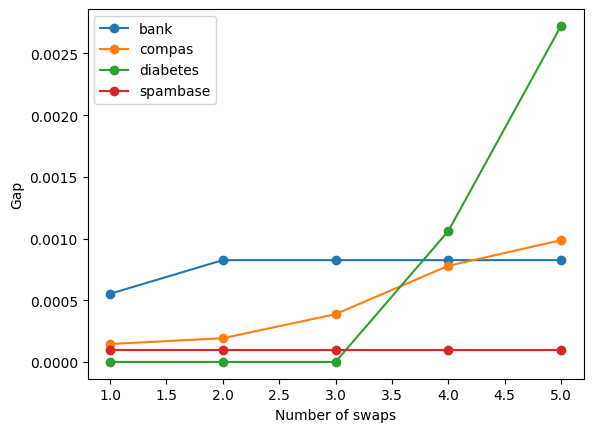

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

with open("results/swaps.pkl", "rb") as f:
    results = pickle.load(f)

results = pd.DataFrame(results, columns=["dataset", "swaps", "gap", "time", "betas", "beta0"])
results["num_solutions"] = results["betas"].apply(lambda x: x.shape[0])

def plot_swaps(results):
    fig, ax = plt.subplots()
    for dataset_name, data_group in results.groupby("dataset"):
        swap_vals = []
        gap_vals = []
        for swaps, swap_group in data_group.groupby("swaps"):
            yields_solutions = swap_group[swap_group["num_solutions"] > 0]
            if not yields_solutions.empty:
                min_gap = yields_solutions["gap"].min()
                swap_vals.append(swaps)
                gap_vals.append(min_gap)
        sorted_pairs = sorted(zip(swap_vals, gap_vals))
        swap_vals, gap_vals = zip(*sorted_pairs)
        ax.plot(swap_vals, gap_vals, label=dataset_name, marker="o")
    ax.set_xlabel("Number of swaps")
    ax.set_ylabel("Gap")
    ax.legend()
    plt.show()
plot_swaps(results)